# Laboratorio L13 (alternativa offline) - Classificare immagini di cifre

B.6 - Data science e Machine Learning: dai dati ai modelli

Da usare se Teachable Machine o la webcam non sono disponibili, oppure come approfondimento.

Dati: dataset delle cifre scritte a mano incluso in scikit-learn (1797 immagini 8 x 8 pixel, derivate dal dataset "Optical Recognition of Handwritten Digits" dell'UCI Machine Learning Repository). Nessun file da caricare.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def controlla(condizione, suggerimento="Non ancora: rileggere la consegna."):
    """Stampa un riscontro immediato sull'esercizio."""
    print("Corretto." if condizione else suggerimento)

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

cifre = load_digits()
print(cifre.images.shape)     # 1797 immagini di 8 x 8 pixel

(1797, 8, 8)


## 1. Un'immagine è una tabella di numeri (esercizio 1)

Ogni pixel ha un valore da 0 (bianco) a 16 (nero). `imshow` disegna la tabella come immagine.

[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]


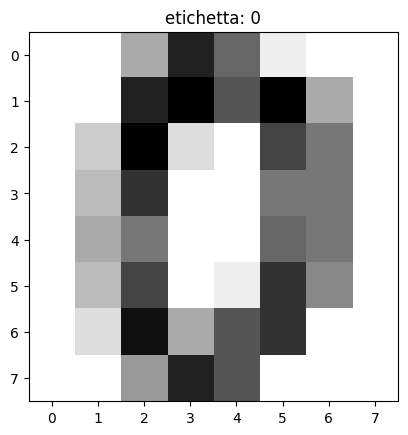

In [2]:
print(cifre.images[0].astype(int))
plt.imshow(cifre.images[0], cmap="gray_r")
plt.title(f"etichetta: {cifre.target[0]}")
plt.show()

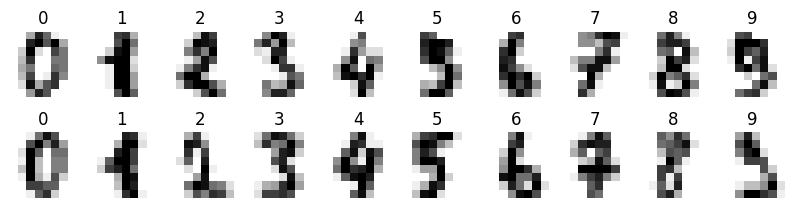

In [3]:
fig, assi = plt.subplots(2, 10, figsize=(10, 2.4))
for k, ax in enumerate(assi.ravel()):
    ax.imshow(cifre.images[k], cmap="gray_r"); ax.set_title(cifre.target[k]); ax.axis("off")
plt.show()

## 2. Da immagine a riga di un dataset (esercizio 2)

Per i modelli di scikit-learn ogni immagine 8 x 8 diventa una riga di 64 numeri, uno per pixel: `cifre.data` ha 1797 righe e 64 colonne. Le caratteristiche sono i pixel.

In [4]:
print(cifre.data.shape)
X_add, X_ver, y_add, y_ver = train_test_split(cifre.data, cifre.target, test_size=0.25, random_state=0, stratify=cifre.target)
knn = KNeighborsClassifier(n_neighbors=3).fit(X_add, y_add)
acc = knn.score(X_ver, y_ver)
print("accuratezza sulla verifica:", round(acc, 3))
controlla(acc > 0.95)

(1797, 64)
accuratezza sulla verifica: 0.987
Corretto.


## 3. Errori (esercizio 3)

In [5]:
previsti = knn.predict(X_ver)
pd.DataFrame(confusion_matrix(y_ver, previsti), index=[f"vera {i}" for i in range(10)], columns=[f"prev. {i}" for i in range(10)])

,prev. 0,prev. 1,prev. 2,prev. 3,prev. 4,prev. 5,prev. 6,prev. 7,prev. 8,prev. 9
vera 0,45,0,0,0,0,0,0,0,0,0
vera 1,0,46,0,0,0,0,0,0,0,0
vera 2,0,0,44,0,0,0,0,0,0,0
vera 3,0,0,0,45,0,0,0,1,0,0
vera 4,0,0,0,0,44,0,0,0,0,1
vera 5,0,0,0,0,0,46,0,0,0,0
vera 6,0,0,0,0,0,0,45,0,0,0
vera 7,0,0,0,0,0,0,0,45,0,0
vera 8,0,1,0,1,0,0,0,0,41,0
vera 9,0,0,0,2,0,0,0,0,0,43


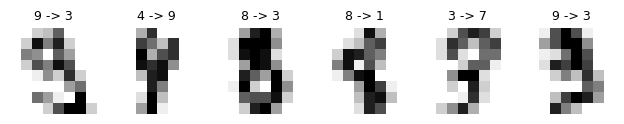

In [6]:
errori = np.where(previsti != y_ver)[0]
fig, assi = plt.subplots(1, len(errori), figsize=(1.3 * len(errori), 1.8))
for ax, i in zip(np.atleast_1d(assi), errori):
    ax.imshow(X_ver[i].reshape(8, 8), cmap="gray_r"); ax.set_title(f"{y_ver[i]} -> {previsti[i]}", fontsize=9); ax.axis("off")
plt.show()

**Domanda**: gli errori sono comprensibili? Una persona avrebbe sbagliato su qualcuna di queste immagini?

Risposta:

## 4. Una scorciatoia (esercizio 4)

Si simula un dataset raccolto male: nelle immagini di addestramento dei "7" si aggiunge una macchia nera di 2 x 2 pixel nell'angolo in alto a sinistra (come una macchia sull'obiettivo della webcam usata per fotografare solo i 7). Si addestra un albero di decisione e lo si valuta su immagini senza macchia e con la macchia.

- `X[condizione, colonne] = 16`: nelle righe che soddisfano la condizione, assegna il valore 16 (nero) alle colonne indicate; i pixel 0, 1, 8, 9 sono il quadrato 2 x 2 in alto a sinistra (la riga di 64 numeri contiene le 8 righe dell'immagine una dopo l'altra)
- `np.ix_(righe, colonne)`: combina una selezione di righe (le immagini di 7) e una di colonne (i pixel della macchia)

In [7]:
from sklearn.tree import DecisionTreeClassifier

MACCHIA = [0, 1, 8, 9]
X_add_sporco = X_add.copy()
X_add_sporco[np.ix_(y_add == 7, MACCHIA)] = 16          # macchia solo sui 7 di addestramento
albero = DecisionTreeClassifier(random_state=0).fit(X_add_sporco, y_add)

prev = albero.predict(X_ver)
print("verifica senza macchia: accuratezza", round((prev == y_ver).mean(), 3),
      "- 7 riconosciuti:", int(((prev == 7) & (y_ver == 7)).sum()), "su", int((y_ver == 7).sum()))

X_ver_macchia = X_ver.copy()
X_ver_macchia[:, MACCHIA] = 16                          # macchia su tutte le immagini di verifica
prev_m = albero.predict(X_ver_macchia)
print("verifica con macchia: immagini classificate come 7:", int((prev_m == 7).sum()), "su", len(y_ver))

verifica senza macchia: accuratezza 0.778 - 7 riconosciuti: 0 su 45
verifica con macchia: immagini classificate come 7: 450 su 450


**Domanda**: che cosa ha imparato il modello? Quale caratteristica dei dati di addestramento ha usato come scorciatoia? Che cosa corrisponde a questa situazione in Teachable Machine?

Risposta: